# 10 · Nowcasting through the pandemic

In the second quarter of 2020 Brazilian GDP fell 8.9 % in a single quarter and grew
7.9 % in the next; industrial production fell almost 20 % in April alone. Shocks of
this size are many standard deviations away from anything in the estimation sample.
A Gaussian dynamic factor model has two problems with them:

* **estimation** — the extreme observations dominate the likelihood, so the loadings,
  factor dynamics and idiosyncratic variances estimated *after* 2020 can be distorted
  for years (Lenza & Primiceri, 2022; Schorfheide & Song, 2021);
* **nowcasting during the episode** — if the extremes are removed, the model cannot see
  the collapse it is supposed to nowcast.

`nowcastbox` offers several answers (innovation I3), all as options of `MixedFreqDFM`:

| option | idea | reference |
|---|---|---|
| `prepare_panel(...)` (default) | replace outliers by a moving median **before** estimation | GRS (2008); R `nowcasting` |
| `idiosyncratic="student_t"` | fat-tailed idiosyncratic errors: extreme observations get small weights in the EM | Antolin-Diaz, Drechsel & Petrella (2017, 2024) |
| `outliers="auto"` | detect outliers **inside** the EM and treat them as missing | Bańbura & Modugno (2014), missing-data EM |
| `covid="dummy"` | intervention dummies on the **factor** for March 2020–December 2021 | Antolin-Diaz et al. (2024) |
| `covid="mask"` / `exclude_periods=` | drop the pandemic months from the estimation | Schorfheide & Song (2021) |

plus a **time-varying long-run mean** of GDP growth (`long_run_mean="time_varying"`,
innovation I4), a related robustness device for slow-moving trend growth.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils import brazil_panel, display, md, pct, setup, show

import nowcastbox as nb

setup()

## 1. Two panels: raw and pre-cleaned

`raw` applies only the stationarity transformations (`replace_outliers=False`);
`clean` is the default `prepare_panel`, which also winsorises extreme observations of
every series — the target included.

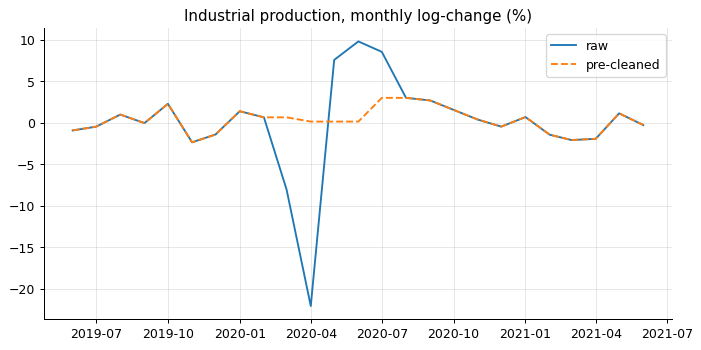

In [2]:
ds, raw = brazil_panel(start="2005-01", replace_outliers=False)
_, clean = brazil_panel(start="2005-01")
fig, ax = plt.subplots()
for name, panel, style in (("raw", raw, "-"), ("pre-cleaned", clean, "--")):
    s = panel.data["pim_geral"].loc["2019-06":"2021-06"]
    ax.plot(s.index.to_timestamp(), 100 * s.to_numpy(), style, label=name)
ax.set_title("Industrial production, monthly log-change (%)")
ax.legend()
show(fig, "10_raw_vs_clean")

## 2. What each option does to the estimated model

All variants share the specification of the previous notebooks: one global factor,
AR(1) idiosyncratic components (white noise for the Student-t variant), estimated on
2005–2026.

In [3]:
variants = {
    "Gaussian, raw data": (raw, {}),
    "Gaussian, pre-cleaned": (clean, {}),
    "Student-t": (raw, {"idiosyncratic": "student_t"}),
    "outliers=auto": (raw, {"outliers": "auto"}),
    "COVID dummies": (raw, {"covid": "dummy"}),
    "COVID mask": (raw, {"covid": "mask"}),
}
fits = {
    name: nb.MixedFreqDFM(n_factors=1, factor_lags=1, max_iter=200, **options).fit(
        panel, target="pib"
    )
    for name, (panel, options) in variants.items()
}
table = pd.DataFrame(
    {
        name: {
            "EM iterations": r.n_iter,
            "loading ibc_br": r.loadings.loc["ibc_br"].iloc[0],
            "loading pim_geral": r.loadings.loc["pim_geral"].iloc[0],
            "idiosyncratic var. pib (x1e3)": 1e3 * r.idiosyncratic_variance["pib"],
            "factor AR coefficient": float(r.transition[0, 0]),
            "nowcast 2026Q3": pct(r.get_nowcast("2026Q3")),
        }
        for name, r in fits.items()
    }
).T
display(table)

,EM iterations,loading ibc_br,loading pim_geral,idiosyncratic var. pib (x1e3),factor AR coefficient,nowcast 2026Q3
"Gaussian, raw data",11,0.3362,0.3706,6.0528,0.0429,0.17%
"Gaussian, pre-cleaned",6,0.2765,0.4237,20.2267,0.0673,-0.04%
Student-t,31,0.2532,0.3738,86.1055,0.0291,-0.15%
outliers=auto,19,0.3362,0.3714,6.5297,0.1313,0.15%
COVID dummies,13,0.3362,0.3707,6.1793,-0.1813,0.13%
COVID mask,17,0.116,0.1453,37.2835,-0.1801,0.36%


The options matter for the *parameters*. Pre-cleaning changes the relative loadings
(more weight on industrial production, less on IBC-Br) and triples the idiosyncratic
variance of GDP, because the cleaned GDP series no longer matches the factor in 2020.
Masking the pandemic months shrinks the loadings by about two thirds: without 2020 the
common factor explains a much smaller share of the variance of the indicators. Outlier
detection and COVID dummies leave the loadings of the raw-data fit almost unchanged —
the factor absorbs the 2020 swing in all three — but change the factor dynamics (the
AR coefficient). (The Student-t variant uses white-noise idiosyncratic terms, so its
variances are not comparable.) The nowcasts for 2026Q3 span about half a percentage
point — larger than a typical monthly nowcast revision.

**How the robust variants see 2020.** The Student-t EM assigns each observation a
weight (1 = normal; small = treated as an outlier); the outlier variant flags
observations; the dummy variant estimates a monthly shift of the factor.

In [4]:
weights = fits["Student-t"].observation_weights
display(weights.loc["2020-02":"2020-08", ["pib", "ibc_br", "pim_geral", "pmc_varejo"]].round(2))

,pib,ibc_br,pim_geral,pmc_varejo
period,,,,
2020-02,NaN,1.21,0.92,1.23
2020-03,0.36,0.07,1.09,0.35
2020-04,NaN,0.18,1.10,0.03
2020-05,NaN,1.09,0.79,0.06
2020-06,0.83,0.56,1.12,0.14
2020-07,NaN,1.21,0.23,0.45
2020-08,NaN,0.85,0.94,0.62


In [5]:
flags = fits["outliers=auto"].outlier_flags
flagged = flags.any(axis=1)
md(
    f"`outliers='auto'` flagged {int(flags.to_numpy().sum())} observations in "
    f"{int(flagged.sum())} months, "
    f"{int(flagged.loc['2020-03':'2021-04'].sum())} of them between March 2020 and "
    "April 2021; the others include the 2008 crisis and the May 2018 truckers' strike."
)

`outliers='auto'` flagged 52 observations in 19 months, 10 of them between March 2020 and April 2021; the others include the 2008 crisis and the May 2018 truckers' strike.

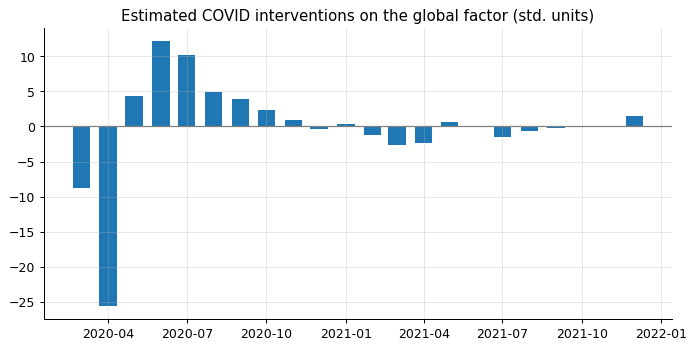

In [6]:
dummies = fits["COVID dummies"].interventions["f1"]
fig, ax = plt.subplots()
ax.bar(dummies.index.to_timestamp(), dummies.to_numpy(), width=20)
ax.axhline(0, color="grey", lw=1)
ax.set_title("Estimated COVID interventions on the global factor (std. units)")
show(fig, "10_dummies")

The dummies capture a collapse of about 26 standard deviations of the factor
innovation in April 2020 and the rebound of May–August, then fade out during 2021.
With the shock absorbed by the dummies, the regular factor dynamics are estimated on
"normal" months.

## 3. Pseudo real-time comparison, 2019Q4–2025Q2

How did each option nowcast GDP *during* and *after* the pandemic? We create one
vintage per quarter (the 20th of its last month) and nowcast that quarter. To keep the
notebook fast, parameters are re-estimated only every 12 vintages (December 2019,
December 2022 — the second estimation includes the pandemic) and the Kalman filter
updates the information in between. Realisations are the published growth rates.

In [7]:
published = nb.apply_transforms(ds.data, ds.transform).to_native("pib")
calendar = nb.load_brazil_calendar()
frames = []
for name, (panel, options) in variants.items():
    backtest = nb.PseudoRealTimeBacktest(
        model=nb.MixedFreqDFM(n_factors=1, factor_lags=1, max_iter=50, **options),
        data=panel,
        target="pib",
        calendar=calendar,
        start="2019-12-20",
        end="2025-06-20",
        step=pd.DateOffset(months=3),
        target_offsets=(0,),
        refit_every=12,
        actual=published,
    )
    frames.append(backtest.run().to_frame().assign(model=name))
errors = pd.concat(frames)
pandemic = pd.period_range("2020Q1", "2021Q4", freq="Q")
errors["window"] = np.where(errors["target_period"].isin(pandemic), "2020-2021", "2022-2025")
rmsfe = errors.groupby(["window", "model"])["error"].apply(
    lambda e: float(100 * np.sqrt(np.mean(np.square(e))))
)
display(rmsfe.unstack("window").round(2).sort_values("2022-2025"))  # noqa: PD010

window,2020-2021,2022-2025
model,,
"Gaussian, raw data",1.51,0.51
outliers=auto,1.49,0.51
COVID mask,1.51,0.53
COVID dummies,1.51,0.53
Student-t,1.68,0.53
"Gaussian, pre-cleaned",3.85,0.62


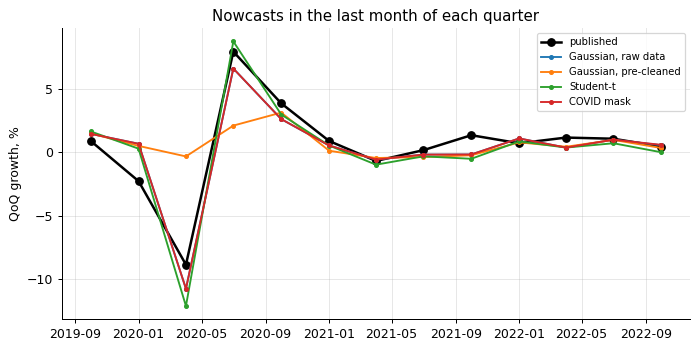

In [8]:
path = errors.pivot_table(index="target_period", columns="model", values="forecast")
fig, ax = plt.subplots()
ax.plot(
    published.loc["2019Q4":"2022Q4"].index.to_timestamp(),
    100 * published.loc["2019Q4":"2022Q4"],
    "k-o",
    lw=2,
    label="published",
)
for name in ("Gaussian, raw data", "Gaussian, pre-cleaned", "Student-t", "COVID mask"):
    p = path[name].loc["2019Q4":"2022Q4"]
    ax.plot(p.index.to_timestamp(), 100 * p, marker=".", label=name)
ax.set_ylabel("QoQ growth, %")
ax.set_title("Nowcasts in the last month of each quarter")
ax.legend(fontsize=8)
show(fig, "10_pandemic_nowcasts")

**Lessons.**

1. **During the episode, keep the data.** The only variant that fails in 2020–2021 is
   the pre-cleaned panel: winsorising removed the April–May 2020 collapse of the
   indicators, so its filter could not see it and its RMSFE is more than twice that of
   every variant using the raw data. Masks, dummies and Student-t errors act on the
   *estimation*; with parameters estimated in December 2019 their filters read the same
   data as the Gaussian model and track the collapse and the rebound equally well.
2. **After the episode, the differences are small.** With the pandemic in the
   estimation sample (refit in December 2022) all raw-data variants have RMSFE of
   0.51–0.53 pp in 2022–2025, against 0.62 pp for the pre-cleaned panel. On this sample
   the payoff of the robust options shows up mainly in the parameter estimates
   (section 2) rather than in point accuracy; it is larger in samples where the
   pandemic months are a bigger share of the data or in density forecasts (notebook 13).
3. **A practical recipe** consistent with these results and with the literature
   (Antolin-Diaz et al., 2024; Lenza & Primiceri, 2022): never winsorise the data the
   nowcast is conditioned on; robustify the *estimation* (Student-t errors or COVID
   dummies); and monitor the outlier weights.

## 4. A time-varying long-run mean (I4)

Antolin-Diaz, Drechsel & Petrella (2017) showed that DFM nowcasts of US GDP were biased
upwards after the 2000s because trend growth had declined. Brazil is a stronger case:
potential growth fell markedly after 2013. With `long_run_mean="time_varying"`, the
mean of GDP growth follows a random walk estimated jointly with the factors.

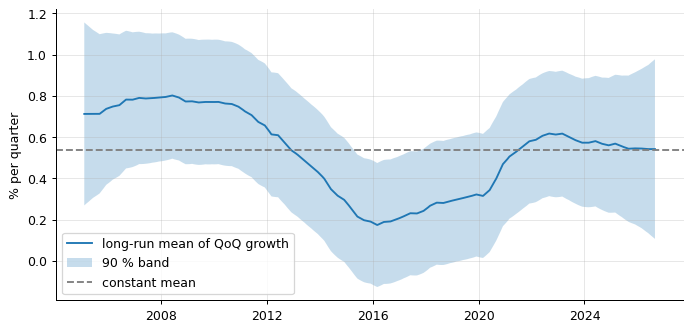

The estimated long-run mean falls from about 0.79% per quarter before the 2014–2016 recession to 0.18% in 2016, and recovers to 0.54% at the end of the sample: a constant-mean model would have overestimated growth for most of the 2010s.

In [9]:
tv = nb.MixedFreqDFM(n_factors=1, factor_lags=1, long_run_mean="time_varying").fit(
    raw, target="pib"
)
lrm = tv.long_run_mean
fig, ax = plt.subplots()
x = lrm.index.to_timestamp()
ax.plot(x, 100 * lrm["pib"], label="long-run mean of QoQ growth")
ax.fill_between(
    x,
    100 * (lrm["pib"] - 1.64 * lrm["pib_std"]),
    100 * (lrm["pib"] + 1.64 * lrm["pib_std"]),
    alpha=0.25,
    label="90 % band",
)
ax.axhline(100 * raw.to_native("pib").mean(), color="grey", ls="--", label="constant mean")
ax.set_ylabel("% per quarter")
ax.legend()
show(fig, "10_long_run_mean")
md(
    f"The estimated long-run mean falls from about {pct(lrm['pib'].loc['2008-02'])} per "
    f"quarter before the 2014–2016 recession to {pct(lrm['pib'].loc['2016-02'])} in 2016, "
    f"and recovers to {pct(lrm['pib'].iloc[-1])} at the end of the sample: a constant-mean "
    "model would have overestimated growth for most of the 2010s."
)

### References

* Antolin-Diaz, J., Drechsel, T. & Petrella, I. (2017). Tracking the slowdown in
  long-run GDP growth. *Review of Economics and Statistics*, 99(2), 343–356.
* Antolin-Diaz, J., Drechsel, T. & Petrella, I. (2024). Advances in nowcasting
  economic activity: the role of heterogeneous dynamics and fat tails. *Journal of
  Econometrics*, 238(2), 105634.
* Bańbura, M. & Modugno, M. (2014). *Journal of Applied Econometrics*, 29(1), 133–160.
* Lenza, M. & Primiceri, G. E. (2022). How to estimate a vector autoregression after
  March 2020. *Journal of Applied Econometrics*, 37(4), 688–699.
* Schorfheide, F. & Song, D. (2021). Real-time forecasting with a (standard)
  mixed-frequency VAR during a pandemic. NBER Working Paper 29535.